<a href="https://colab.research.google.com/github/Jeanritah/ai-sustainable-routing/blob/main/Bologna_Cool_Routing_Proof_of_ConceptT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Bologna Cool Routing Proof of Concept


## Goal
Can we route pedestrians through Bologna along paths that are **cooler and greener**, not just shorter?

## Approach
1. Download Bologna's walking street network (OpenStreetMap)
2. Load heat & vegetation data from the **TALEA** grid (100×100m cells covering all of Bologna)
3. Assign each street a **comfort cost** based on heat + greenery
4. Compare two routes: **shortest** vs **comfort-optimised**

## Key Data Sources
| Source | What it gives us |
|--------|------------------|
| [OSMnx](https://osmnx.readthedocs.io/) | Bologna's walking street network |
| [TALEA Green Cells](https://github.com/SimReale/TALEA_Green_Cells) | UHEI (heat) + NDVI (vegetation) per 100m grid cell |

### Key Terms
- **UHEI** — Urban Heat Exposure Index. Higher = hotter street.
- **NDVI** — Normalized Difference Vegetation Index. Higher = more greenery.
- **Comfort cost** — Our custom weight: penalises heat, rewards greenery.

---
## Getting the Heat & Vegetation Data
We clone the TALEA repository, which contains a pre-processed 100×100m grid of Bologna with heat and vegetation measurements for each cell.

In [1]:
# Clone the TALEA Green Cells repository
!git clone https://github.com/SimReale/TALEA_Green_Cells.git

# List available dataset files
import os
files = os.listdir('TALEA_Green_Cells/dataset/processed_data/full')
print("Available dataset files:")
for f in files:
    print(f"  {f}")

Cloning into 'TALEA_Green_Cells'...
remote: Enumerating objects: 1252, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1252 (delta 3), reused 0 (delta 0), pack-reused 1243 (from 1)
Receiving objects: 100% (1252/1252), 827.80 MiB | 23.87 MiB/s, done.
Resolving deltas: 100% (584/584), done.
Updating files: 100% (422/422), done.
Available dataset files:
  grid_with_areas.geojson
  trees_outside_green.geojson
  densities_grid.geojson
  aree_statistiche_grid.geojson
  final_grid.geojson


---
##Loading and Inspect the Grid
The main file `final_grid.geojson` contains **11,560 cells** covering all of Bologna.
Each cell has 23 attributes — the two we care most about are `weighted_uhei` (heat) and `weighted_ndvi` (vegetation).

In [2]:
import geopandas as gpd

# Loading the city wide grid
grid = gpd.read_file('TALEA_Green_Cells/dataset/processed_data/full/final_grid.geojson')

print(f"Grid shape: {grid.shape}  →  {grid.shape[0]} cells × {grid.shape[1]} columns")
print(f"\nColumns: {list(grid.columns)}")
print("\nSample row:")
print(grid[['weighted_uhei', 'weighted_ndvi', 'green_pc', 'geometry']].head(3))

Grid shape: (11560, 23)  →  11560 cells × 23 columns

Columns: ['id', 'left', 'top', 'right', 'bottom', 'row_index', 'col_index', 'green_area', 'green_pc', 'buildings_area', 'buildings_pc', 'road_area', 'road_pc', 'free_space_area', 'free_space_pc', 'railways_area', 'railways_pc', 'free_space_number', 'weighted_uhei', 'weighted_ndvi', 'tree_number', 'inverse_uhei', 'geometry']

Sample row:
   weighted_uhei  weighted_ndvi   green_pc  \
0       1.986260       0.215911  41.916085   
1       1.923523       0.252438  77.785889   
2       1.937350       0.363167  57.940685   

                                            geometry  
0  MULTIPOLYGON (((1253649.035 5546849.468, 12536...  
1  MULTIPOLYGON (((1253613.775 5546781.344, 12536...  
2  MULTIPOLYGON (((1253549.035 5546656.258, 12535...  


---
## Visualising the Heat and Vegetation Across Bologna
Before building our routing model, we visualise the raw data to confirm our hypothesis:
- The **city centre and northern districts** (e.g. Bolognina) are hotter and have less greenery.
- The **Colli hills to the south** are cooler and greener.

These maps also validate that TALEA data is sensible.

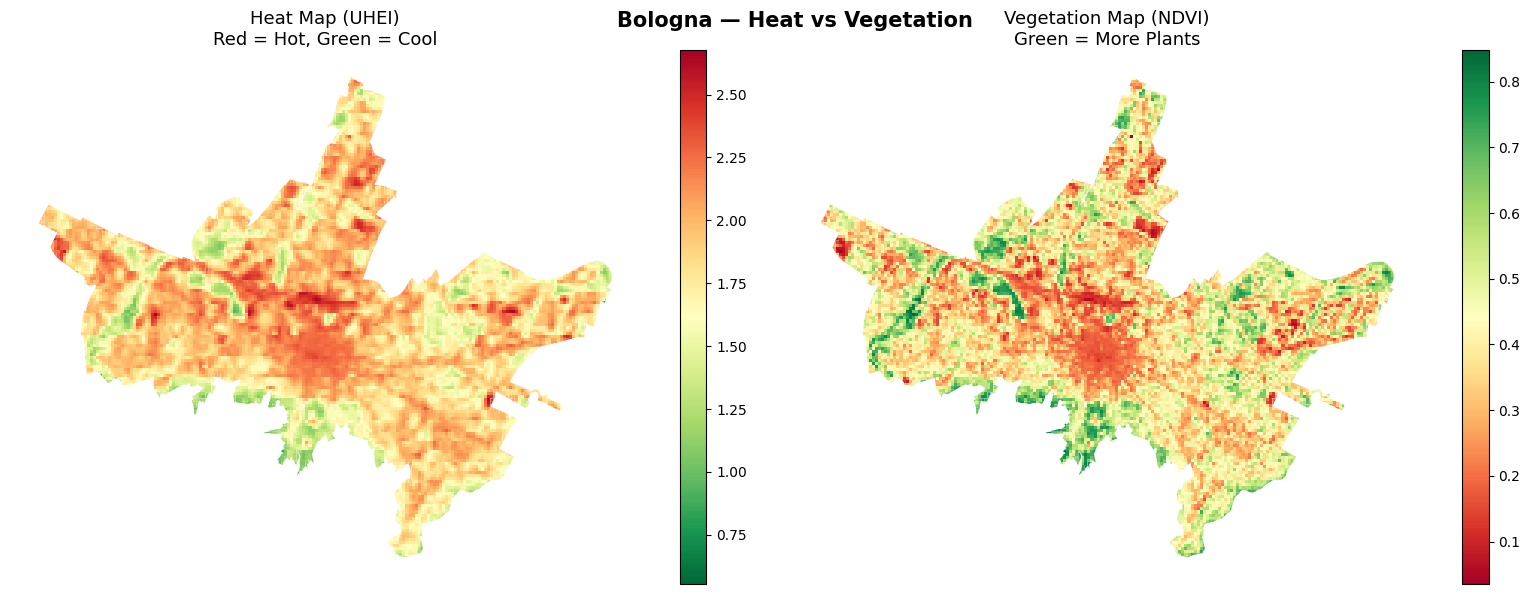

Saved: bologna_heat_vegetation.png


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Heat map (UHEI) — red = hot
grid.plot(column='weighted_uhei', cmap='RdYlGn_r', legend=True, ax=axes[0])
axes[0].set_title('Heat Map (UHEI)\nRed = Hot, Green = Cool', fontsize=13)
axes[0].axis('off')

# Right: Vegetation map (NDVI) — green = lots of plants
grid.plot(column='weighted_ndvi', cmap='RdYlGn', legend=True, ax=axes[1])
axes[1].set_title('Vegetation Map (NDVI)\nGreen = More Plants', fontsize=13)
axes[1].axis('off')

plt.suptitle('Bologna — Heat vs Vegetation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bologna_heat_vegetation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bologna_heat_vegetation.png")

---
## Downloading Bologna's Walking Street Network
We use **OSMnx** to download every walkable street in Bologna from OpenStreetMap.
The result is a graph where **nodes = intersections** and **edges = street segments**.

In [4]:
!pip install osmnx -q

import osmnx as ox
import networkx as nx

# Download Bologna's walking network
G = ox.graph_from_place('Bologna, Italy', network_type='walk')

print(f"Network loaded!")
print(f"  Nodes (intersections): {len(G.nodes):,}")
print(f"  Edges (street segments): {len(G.edges):,}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00
Network loaded!
  Nodes (intersections): 24,584
  Edges (street segments): 66,156


---
## Joining the  Street Network with Heat Data
We spatially join the TALEA heat grid to each street segment, so every edge in our graph gets assigned `weighted_uhei` and `weighted_ndvi` values.

*NB..* One street segment can overlap multiple 100m grid cells. The spatial join creates duplicate rows in that case. We fix this by **averaging** the heat/vegetation values per street segment.

In [5]:
# Convert the graph edges to a GeoDataFrame
edges = ox.graph_to_gdfs(G, nodes=False)
edges = edges.reset_index()  # makes u, v, key accessible as columns

print(f"Edges before join: {len(edges):,}")
print(f"Grid CRS: {grid.crs}")
print(f"Edges CRS: {edges.crs}")

# Match CRS — both must be in the same projection
grid_reproj = grid.to_crs(edges.crs)

# Spatial join: assign each street the heat cell it overlaps with
edges_with_heat = gpd.sjoin(
    edges[['u', 'v', 'key', 'length', 'name', 'geometry']],
    grid_reproj[['weighted_uhei', 'weighted_ndvi', 'geometry']],
    how='left',
    predicate='intersects'
)
print(f"\nEdges after spatial join: {len(edges_with_heat):,}  ← duplicates from multi-cell overlap")

# Fix duplicates: average UHEI and NDVI per unique street segment
edges_fixed = edges_with_heat.groupby(['u', 'v', 'key']).agg(
    weighted_uhei=('weighted_uhei', 'mean'),
    weighted_ndvi=('weighted_ndvi', 'mean'),
    length=('length', 'first'),
    name=('name', 'first')
).reset_index()

# Fill any missing values with city-wide mean
edges_fixed['weighted_uhei'].fillna(edges_fixed['weighted_uhei'].mean(), inplace=True)
edges_fixed['weighted_ndvi'].fillna(edges_fixed['weighted_ndvi'].mean(), inplace=True)

print(f"Edges after deduplication: {len(edges_fixed):,}  ← back to original count")

# Sanity check: show greenest and hottest streets
print("\nGreenest streets (highest NDVI):")
print(edges_fixed.nlargest(3, 'weighted_ndvi')[['name', 'weighted_ndvi', 'weighted_uhei']])
print("\nHottest streets (highest UHEI):")
print(edges_fixed.nlargest(3, 'weighted_uhei')[['name', 'weighted_ndvi', 'weighted_uhei']])

Edges before join: 66,156
Grid CRS: EPSG:3857
Edges CRS: epsg:4326

Edges after spatial join: 111,754  ← duplicates from multi-cell overlap
Edges after deduplication: 66,156  ← back to original count

Greenest streets (highest NDVI):
      name  weighted_ndvi  weighted_uhei
4727  None       0.822907       1.045266
4905  None       0.822907       1.045266
4729  None       0.814222       0.992400

Hottest streets (highest UHEI):
       name  weighted_ndvi  weighted_uhei
25981  None       0.131845       2.650305
25982  None       0.131845       2.650305
25983  None       0.131845       2.650305


/tmp/ipykernel_1663/127744177.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  edges_fixed['weighted_uhei'].fillna(edges_fixed['weighted_uhei'].mean(), inplace=True)
/tmp/ipykernel_1663/127744177.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

---
##  BuildING  the Comfort Cost Function
Each street edge gets a **comfort cost** — a single number that captures how pleasant (or unpleasant) it is to walk along.

### Formula
```
comfort_cost = 0.2 × length_norm + 0.4 × uhei_norm + 0.4 × (1 − ndvi_norm)
```

| Component | Weight | Meaning |
|-----------|--------|---------|
| `length_norm` | 20% | Shorter streets are preferred |
| `uhei_norm` | 40% | Hotter streets have higher cost |
| `1 − ndvi_norm` | 40% | Streets with less greenery have higher cost |

All values are **normalised to [0, 1]** before combining, so they're on the same scale.

> **Why 80% comfort, 20% distance?** We experimented and found that a 50/50 split produced nearly identical routes (the heat variation in Bologna isn't large enough to overcome distance alone). Pushing to 80% comfort produces meaningfully different — and noticeably cooler/greener — routes.

In [6]:
# Normalise each feature to [0, 1]
uhei_min, uhei_max = edges_fixed['weighted_uhei'].min(), edges_fixed['weighted_uhei'].max()
ndvi_min, ndvi_max = edges_fixed['weighted_ndvi'].min(), edges_fixed['weighted_ndvi'].max()
len_min,  len_max  = edges_fixed['length'].min(),        edges_fixed['length'].max()

edges_fixed['uhei_norm']   = (edges_fixed['weighted_uhei'] - uhei_min) / (uhei_max - uhei_min)
edges_fixed['ndvi_norm']   = (edges_fixed['weighted_ndvi'] - ndvi_min) / (ndvi_max - ndvi_min)
edges_fixed['length_norm'] = (edges_fixed['length']        - len_min)  / (len_max  - len_min)

# Comfort cost: penalise heat, reward greenery, consider distance
edges_fixed['comfort_cost'] = (
    0.2 * edges_fixed['length_norm'] +
    0.4 * edges_fixed['uhei_norm'] +
    0.4 * (1 - edges_fixed['ndvi_norm'])
)

# Update graph edges with the new comfort cost and raw values
print("Updating graph edges with comfort costs...")
for _, row in edges_fixed.iterrows():
    u, v, k = int(row['u']), int(row['v']), int(row['key'])
    if G.has_edge(u, v, k):
        G[u][v][k]['comfort_cost']  = float(row['comfort_cost'])
        G[u][v][k]['weighted_uhei'] = float(row['weighted_uhei'])
        G[u][v][k]['weighted_ndvi'] = float(row['weighted_ndvi'])

print("Done! Comfort cost range:")
print(f"  Min: {edges_fixed['comfort_cost'].min():.3f}")
print(f"  Max: {edges_fixed['comfort_cost'].max():.3f}")
print(f"  Mean: {edges_fixed['comfort_cost'].mean():.3f}")

Updating graph edges with comfort costs...
Done! Comfort cost range:
  Min: 0.010
  Max: 0.770
  Mean: 0.489


---
## ComputING  and Compare Routes
We test a route from **Bolognina** (hot, dense northern district) to **Giardini Margherita** (the large green park in the south) — a corridor that should show a clear contrast.

Two routes are computed using NetworkX's `shortest_path`:
- **Route 1 (Shortest):** minimises `length` only
- **Route 2 (Comfort):** minimises `comfort_cost`

In [7]:
# DefinING start and end points
start_lat, start_lon = 44.5150, 11.3450   # Bolognina (hot, northern district)
end_lat,   end_lon   = 44.4850, 11.3550   # Giardini Margherita (green park, south)

# Find nearest graph nodes
start_node = ox.distance.nearest_nodes(G, start_lon, start_lat)
end_node   = ox.distance.nearest_nodes(G, end_lon,   end_lat)

# Compute routes
route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

# Helper functions to measure route quality
def route_metric(G, route, attr, default):
    """Average a graph edge attribute over a route."""
    values = []
    for u, v in zip(route[:-1], route[1:]):
        k = list(G[u][v].keys())[0]
        values.append(G[u][v][k].get(attr, default))
    return sum(values) / len(values)

def route_distance(G, route):
    """Total length of a route in metres."""
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        k = list(G[u][v].keys())[0]
        total += G[u][v][k].get('length', 0)
    return total

# Measure both routes
dist_short,   dist_comfort   = route_distance(G, route_short),  route_distance(G, route_comfort)
heat_short,   heat_comfort   = route_metric(G, route_short, 'weighted_uhei', 2.0),  route_metric(G, route_comfort, 'weighted_uhei', 2.0)
green_short,  green_comfort  = route_metric(G, route_short, 'weighted_ndvi', 0.3),  route_metric(G, route_comfort, 'weighted_ndvi', 0.3)

# Print results
print("=" * 45)
print(f"  Route:      Shortest    Comfort")
print("=" * 45)
print(f"  Distance:   {dist_short:.0f}m      {dist_comfort:.0f}m")
print(f"  Avg UHEI:   {heat_short:.4f}      {heat_comfort:.4f}")
print(f"  Avg NDVI:   {green_short:.4f}      {green_comfort:.4f}")
print("=" * 45)
print(f"\n  Comfort route is:")
print(f"    {((heat_short - heat_comfort) / heat_short * 100):.1f}% COOLER")
print(f"    {((green_comfort - green_short) / green_short * 100):.1f}% GREENER")
print(f"    {dist_comfort - dist_short:.0f}m longer  (~{(dist_comfort - dist_short) / 80:.0f} min extra walking)")

  Route:      Shortest    Comfort
  Distance:   4565m      4801m
  Avg UHEI:   2.1118      2.0701
  Avg NDVI:   0.2791      0.3035

  Comfort route is:
    2.0% COOLER
    8.7% GREENER
    236m longer  (~3 min extra walking)


---
##  Interactive Map
We visualise both routes on an interactive Folium map.
- **Red line** → Shortest route (faster, but hotter)
- **Green line** → Comfort route (slightly longer, cooler and greener)

Hover over each route to see its label. Click the markers for start/end info.

In [8]:
import folium

# Create map centred on Bologna
m = folium.Map(location=[44.4949, 11.3426], zoom_start=14)

def route_to_coords(G, route):
    """Convert a list of node IDs to (lat, lon) pairs for Folium."""
    return [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

# Draw routes
folium.PolyLine(
    route_to_coords(G, route_short),
    color='red', weight=5, opacity=0.8,
    tooltip=f'Shortest Route ({dist_short:.0f}m)'
).add_to(m)

folium.PolyLine(
    route_to_coords(G, route_comfort),
    color='green', weight=5, opacity=0.8,
    tooltip=f'Comfort Route ({dist_comfort:.0f}m — cooler & greener)'
).add_to(m)

# Add start/end markers
coords_short = route_to_coords(G, route_short)
folium.Marker(coords_short[0],  popup='START: Bolognina',           icon=folium.Icon(color='blue',   icon='play')).add_to(m)
folium.Marker(coords_short[-1], popup='END: Giardini Margherita',   icon=folium.Icon(color='purple', icon='stop')).add_to(m)

# Add legend
legend_html = f"""
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:15px; border-radius:10px;
     border:2px solid grey; font-size:14px; line-height:1.8">
    <b>Bologna Cool Routing — Results</b><br><br>
    <span style="color:red">━━━</span> Shortest Route ({dist_short:.0f}m)<br>
    <span style="color:green">━━━</span> Comfort Route ({dist_comfort:.0f}m)<br><br>
    <b>Comfort route improvement:</b><br>
    {((green_comfort-green_short)/green_short*100):.1f}% greener (NDVI)<br>
    {((heat_short-heat_comfort)/heat_short*100):.1f}% cooler (UHEI)<br>
    +{dist_comfort-dist_short:.0f}m extra walking
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('bologna_cool_routing.html')
print("Map saved as 'bologna_cool_routing.html'")
print("Download and open in your browser to explore interactively!")

Map saved as 'bologna_cool_routing.html'
Download and open in your browser to explore interactively!


In [9]:
# Download the map file to computer
from google.colab import files
files.download('bologna_cool_routing.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#RESULTS

| Metric | Shortest Route | Comfort Route | Improvement |
|--------|---------------|--------------|-------------|
| Distance | 4,565 m | 4,801 m | +236 m (+5.2%) |
| Avg UHEI (heat) | 2.1118 | 2.0701 | −2.0% cooler |
| Avg NDVI (greenery) | 0.2791 | 0.3035 | +8.7% greener |

**Key Takeaways:**
- The comfort route is meaningfully **greener (+8.7%)** for only ~3 minutes of extra walking.
- Heat reduction (−2.0%) is modest — UHEI variation in Bologna is relatively compressed (range: 0.55–2.68), so large heat gaps between paths are rare.
- **Vegetation (NDVI) is the stronger differentiator** for comfort routing in Bologna.
- The proof of concept validates the approach. Next steps: test more route pairs and tune weights.





